In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

# Progress bar
from tqdm.auto import tqdm
tqdm.pandas()

pd.set_option('display.max_columns', None)

In [3]:
from news_featuring import extract_news_features_pipeline

# Load and preprocess events

> Upload

In [4]:
PATH_TO_NEWS = 'economic_events/economic_events.csv'
news = pd.read_csv(PATH_TO_NEWS)
news = news[['date', 'currency', 'importance', 'title', 'indicator', 'country', 'category', 'actual', 'forecast', 'previous', 
             'comment', 'source', 'source_url', 'referenceDate', 'period', 'unit', 'scale']]
news['date'] = pd.to_datetime(news['date'], utc=True)
news.sort_values(by='date', ascending=True, inplace=True)

In [5]:
print(f'Start date: {news['date'].dt.date.min()}')
print(f'End date: {news['date'].dt.date.max()}')
print(f'Count of rows: {news.shape[0]}')
print(f'Shape: {news.shape}')

Start date: 2013-01-04
End date: 2026-03-30
Count of rows: 99029
Shape: (99029, 17)


> Extract features

In [6]:
news = extract_news_features_pipeline(news)

[INFO] Category dummies added.
[INFO] Currency dummies added.
[INFO] Country dummies added.
[INFO] Source dummies added.
[INFO] Event category dummies added.
[INFO] Stage release dummies added.
[INFO] Event calculation period dummies added.
[INFO] Scale dummies added.
[INFO] Most important event dummies added.
[INFO] Flag "is_calendar" added.
[INFO] Flag "is_president" added.
[INFO] Flag "is_election" added.
[INFO] Removed "OTHER" and redundant columns.


In [7]:
news.head(2)

,date,importance,title,indicator,actual,forecast,previous,comment,referenceDate,period,unit,category_bnd,category_bsnss,category_cnsm,category_enrg,category_gdp,category_gov,category_hse,category_lbr,category_mny,category_mrkt,category_prce,category_trd,currency_AUD,currency_CAD,currency_EUR,currency_GBP,currency_JPY,currency_SEK,currency_SGD,currency_USD,country_AU,country_CA,country_DE,country_EU,country_FR,country_GB,country_JP,country_SE,country_SG,country_US,source_CENTRAL_BANK,source_ENERGY,source_GOV_MINISTRY,source_INDUSTRY,source_OFFICES,source_OFFICIAL_STATS,source_PRIVATE_SURVEY,source_RATING_AGENCY,source_RESEARCH_INSTITUTES,source_US_HOUSING,event_MONETARY_POLICY,event_CB_SPEECH,event_INFLATION,event_LABOR_MARKET,event_ECONOMIC_ACTIVITY,event_SENTIMENT,event_CONSUMER_HOUSING,event_TRADE_FINANCE,event_COMMODITIES,stage_release_Final,stage_release_Flash,stage_release_Preliminary,calc_period_MoM,calc_period_QoQ,calc_period_YoY,scale_B,scale_K,scale_M,scale_T,mie,mie_Balance_of_Trade,mie_Core_Inflation_rate,mie_FOMC,mie_GDP,mie_Inflation_rate,mie_Interest_Rate_Decision,mie_NFP,mie_PMI,mie_PMI_Manufacturing,mie_PMI_Services,mie_Retail_Sales,mie_Unemployment_rate,is_calendar,is_president,is_election
0,2013-01-04 13:30:00+00:00,1,Non Farm Payrolls,Non Farm Payrolls,NaN,NaN,NaN,Nonfarm payrolls is an employment report relea...,2012-12-31T00:00:00Z,DEC 2012,NaN,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NFP,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,2013-01-04 13:30:00+00:00,0,Unemployment Rate,Unemployment Rate,NaN,NaN,NaN,"In the United States, the unemployment rate me...",2012-12-31T00:00:00Z,DEC 2012,NaN,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Unemployment_rate,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


> Aggregate time

## 1st method:
> Just floor datetime to earlier date and then shift this dt backward on 30min

In [8]:
news['date'] = pd.to_datetime(news['date'], utc=True)
news['rounded_time'] = news['date'].apply(lambda x: x.floor('1h'))

In [9]:
news.head()

,date,importance,title,indicator,actual,forecast,previous,comment,referenceDate,period,unit,category_bnd,category_bsnss,category_cnsm,category_enrg,category_gdp,category_gov,category_hse,category_lbr,category_mny,category_mrkt,category_prce,category_trd,currency_AUD,currency_CAD,currency_EUR,currency_GBP,currency_JPY,currency_SEK,currency_SGD,currency_USD,country_AU,country_CA,country_DE,country_EU,country_FR,country_GB,country_JP,country_SE,country_SG,country_US,source_CENTRAL_BANK,source_ENERGY,source_GOV_MINISTRY,source_INDUSTRY,source_OFFICES,source_OFFICIAL_STATS,source_PRIVATE_SURVEY,source_RATING_AGENCY,source_RESEARCH_INSTITUTES,source_US_HOUSING,event_MONETARY_POLICY,event_CB_SPEECH,event_INFLATION,event_LABOR_MARKET,event_ECONOMIC_ACTIVITY,event_SENTIMENT,event_CONSUMER_HOUSING,event_TRADE_FINANCE,event_COMMODITIES,stage_release_Final,stage_release_Flash,stage_release_Preliminary,calc_period_MoM,calc_period_QoQ,calc_period_YoY,scale_B,scale_K,scale_M,scale_T,mie,mie_Balance_of_Trade,mie_Core_Inflation_rate,mie_FOMC,mie_GDP,mie_Inflation_rate,mie_Interest_Rate_Decision,mie_NFP,mie_PMI,mie_PMI_Manufacturing,mie_PMI_Services,mie_Retail_Sales,mie_Unemployment_rate,is_calendar,is_president,is_election,rounded_time
0,2013-01-04 13:30:00+00:00,1,Non Farm Payrolls,Non Farm Payrolls,NaN,NaN,NaN,Nonfarm payrolls is an employment report relea...,2012-12-31T00:00:00Z,DEC 2012,NaN,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NFP,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,2013-01-04 13:00:00+00:00
1,2013-01-04 13:30:00+00:00,0,Unemployment Rate,Unemployment Rate,NaN,NaN,NaN,"In the United States, the unemployment rate me...",2012-12-31T00:00:00Z,DEC 2012,NaN,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Unemployment_rate,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2013-01-04 13:00:00+00:00
2,2013-01-06 13:00:00+00:00,-1,Inflation Rate MoM Flash,Inflation Rate Mom,NaN,NaN,0.2,"In Germany, the most important categories in t...",2013-12-31T00:00:00Z,Dec 2013,%,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,Inflation_rate,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2013-01-06 13:00:00+00:00
3,2013-01-17 09:30:00+00:00,-1,Retail Sales ex Fuel MoM,Retail Sales Ex Fuel,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",2013-12-31T00:00:00Z,Dec 2013,NaN,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,1,0,0,0,0,0,0,Retail_Sales,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2013-01-17 09:00:00+00:00
4,2013-01-17 09:30:00+00:00,-1,Retail Sales ex Fuel YoY,Retail Sales Ex Fuel,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",2013-12-31T00:00:00Z,Dec 2013,NaN,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,1,0,0,0,0,Retail_Sales,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2013-01-17 09:00:00+00:00


In [10]:
news['mie'].value_counts()

mie
Inflation_rate            8513
Retail_Sales              3505
GDP                       2992
PMI_Manufacturing         2627
PMI                       2454
PMI_Services              2070
Core_Inflation_rate       1907
Balance_of_Trade          1633
Unemployment_rate         1371
Interest_Rate_Decision     751
NFP                        426
FOMC                       155
Name: count, dtype: int64

## 2nd method:
> Find the nearest hour or 30 min and crop dt to the nearest one. Then shift this dt backward on 30min"

In [11]:
from news_featuring import floor_or_ceil

In [13]:
news['date'] = pd.to_datetime(news['date'], utc=True)
news['rounded_time'] = news['date'].apply(lambda x: floor_or_ceil(x, freq='h'))
news['time_to_check'] = news['rounded_time'] - pd.Timedelta(hours=1)  # Important: this feature allows to check the market 30 min before the news comes out

In [15]:
news[['date', 'rounded_time', 'time_to_check']]

,date,rounded_time,time_to_check
0,2013-01-04 13:30:00+00:00,2013-01-04 14:00:00+00:00,2013-01-04 13:00:00+00:00
1,2013-01-04 13:30:00+00:00,2013-01-04 14:00:00+00:00,2013-01-04 13:00:00+00:00
2,2013-01-06 13:00:00+00:00,2013-01-06 13:00:00+00:00,2013-01-06 12:00:00+00:00
3,2013-01-17 09:30:00+00:00,2013-01-17 10:00:00+00:00,2013-01-17 09:00:00+00:00
4,2013-01-17 09:30:00+00:00,2013-01-17 10:00:00+00:00,2013-01-17 09:00:00+00:00
...,...,...,...
99021,2026-03-30 23:30:00+00:00,2026-03-31 00:00:00+00:00,2026-03-30 23:00:00+00:00
99026,2026-03-30 23:50:00+00:00,2026-03-31 00:00:00+00:00,2026-03-30 23:00:00+00:00
99027,2026-03-30 23:50:00+00:00,2026-03-31 00:00:00+00:00,2026-03-30 23:00:00+00:00
99025,2026-03-30 23:50:00+00:00,2026-03-31 00:00:00+00:00,2026-03-30 23:00:00+00:00


## Aggreagate events

In [11]:
from news_featuring import aggregate_events

In [12]:
news.shape

(99029, 87)

In [13]:
agg_events = aggregate_events(news, dt_col='rounded_time')

In [14]:
agg_events['time_to_check'] = agg_events['rounded_time'] - pd.Timedelta(hours=1)

In [15]:
agg_events.shape

(33564, 84)

In [16]:
agg_events.isna().sum().sort_values(ascending=False)

prev_hour_main_event             1
next_hour_main_event             1
last_important_event_in_hours    1
rounded_time                     0
key_event_count                  0
                                ..
mie_PMI_Services                 0
mie_Unemployment_rate            0
time_passed_from_last_events     0
time_left_to_next_events         0
time_to_check                    0
Length: 84, dtype: int64

In [17]:
agg_events.head()

,rounded_time,news_count,high_impact_count,key_event_count,main_event,prev_hour_news_count,next_hour_news_count,prev_hour_high_impact_count,next_hour_high_impact_count,prev_hour_main_event,next_hour_main_event,category_bnd,category_bsnss,category_cnsm,category_enrg,category_gdp,category_gov,category_hse,category_lbr,category_mny,category_mrkt,category_prce,category_trd,currency_AUD,currency_CAD,currency_EUR,currency_GBP,currency_JPY,currency_SEK,currency_SGD,currency_USD,country_AU,country_CA,country_DE,country_EU,country_FR,country_GB,country_JP,country_SE,country_SG,country_US,source_CENTRAL_BANK,source_ENERGY,source_GOV_MINISTRY,source_INDUSTRY,source_OFFICES,source_OFFICIAL_STATS,source_PRIVATE_SURVEY,source_RATING_AGENCY,source_RESEARCH_INSTITUTES,source_US_HOUSING,event_MONETARY_POLICY,event_CB_SPEECH,event_INFLATION,event_LABOR_MARKET,event_ECONOMIC_ACTIVITY,event_SENTIMENT,event_CONSUMER_HOUSING,event_TRADE_FINANCE,event_COMMODITIES,stage_release_Final,stage_release_Flash,stage_release_Preliminary,calc_period_MoM,calc_period_QoQ,calc_period_YoY,is_calendar,is_president,mie_Balance_of_Trade,mie_Core_Inflation_rate,mie_FOMC,mie_GDP,mie_Inflation_rate,mie_Interest_Rate_Decision,mie_NFP,mie_PMI,mie_PMI_Manufacturing,mie_PMI_Services,mie_Retail_Sales,mie_Unemployment_rate,time_passed_from_last_events,time_left_to_next_events,last_important_event_in_hours,time_to_check
0,2013-01-04 13:00:00+00:00,2,1,2,NFP,0.0,1.0,0.0,0.0,None,Inflation_rate,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,0,1,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0.0,96.0,NaN,2013-01-04 12:00:00+00:00
1,2013-01-06 13:00:00+00:00,1,0,1,Inflation_rate,2.0,5.0,1.0,0.0,NFP,Retail_Sales,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,96.0,520.0,48.0,2013-01-06 12:00:00+00:00
2,2013-01-17 09:00:00+00:00,5,0,5,Retail_Sales,1.0,27.0,0.0,0.0,Inflation_rate,Unemployment_rate,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,10,0,0,0,0,0,2,0,3,0,0,0,0,0,0,0,0,0,0,0,0,5,0,520.0,288.0,260.0,2013-01-17 08:00:00+00:00
3,2013-01-23 09:00:00+00:00,27,0,1,Unemployment_rate,5.0,1.0,0.0,0.0,Retail_Sales,No main events,0,2,0,0,0,11,0,1,13,0,0,0,0,0,10,3,0,4,0,10,0,0,0,10,0,3,0,4,0,10,13,0,0,0,0,1,0,0,0,0,15,16,0,2,0,0,2,2,0,0,0,0,0,0,0,7,1,0,0,0,0,0,0,0,0,0,0,0,1,288.0,104.0,144.0,2013-01-23 08:00:00+00:00
4,2013-01-25 13:00:00+00:00,1,0,0,No main events,27.0,1.0,0.0,0.0,Unemployment_rate,No main events,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,104.0,170.0,52.0,2013-01-25 12:00:00+00:00


## Load prices

In [18]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

files = os.listdir("../dataset/prices")
pairs = [p.split('_')[0] for p in files]

In [19]:
import pytz
from datetime import datetime
import MetaTrader5 as mt5

In [27]:
mt5.initialize()

True

In [28]:
timezone = pytz.timezone("Etc/UTC")
utc_from = datetime(2015, 1, 1, tzinfo=timezone)
utc_to = datetime.now(tz=timezone)

In [29]:
def download_ticker_mt5(ticker: str, utc_from: datetime, date_to: datetime=datetime.now()):
    ticker = ticker.upper()

    # get rates
    rates = mt5.copy_rates_range(ticker, mt5.TIMEFRAME_H1, utc_from, date_to)

    df = pd.DataFrame(rates)
    df['time']=pd.to_datetime(df['time'], unit='s')
    # df.set_index('time', inplace=True)
    
    return df

In [30]:
def download_ticker_mt5_from(ticker: str, tf = mt5.TIMEFRAME_H1, date_to: datetime=datetime.now(), n_last: int = 99000):
    ticker = ticker.upper()

    # get rates
    rates = mt5.copy_rates_from(ticker, tf, date_to, n_last)

    df = pd.DataFrame(rates)
    df['time']=pd.to_datetime(df['time'], unit='s')
    
    return df

In [31]:
# rates = mt5.copy_rates_from("EURUSD", mt5.TIMEFRAME_H1, datetime.now(), 99000)
# rates = pd.DataFrame(rates)
# rates['time'] = pd.to_datetime(rates['time'], unit='s')

In [ ]:
# def check_missing_business_days(df, date_column):
#     # Ensure the 'date' column is of datetime type
#     df[date_column] = pd.to_datetime(df[date_column])

#     # Create a list of business days (Mon-Fri)
#     business_days = pd.date_range(start=df[date_column].min(), end=df[date_column].max(), freq='B')

#     # Find missing business days
#     missing_days = pd.Series(list(set(business_days).difference(set(df[date_column])))).sort_values(ignore_index=True)

#     return missing_days

In [67]:
# check_missing_business_days(rates, 'time')

In [19]:
download_ticker_mt5('EURUSD', utc_from, utc_to)

,time,open,high,low,close,tick_volume,spread,real_volume
0,2015-01-02 09:00:00,1.20538,1.20576,1.20344,1.20553,3783,10,0
1,2015-01-02 10:00:00,1.20554,1.20690,1.20443,1.20467,4626,11,0
2,2015-01-02 11:00:00,1.20467,1.20600,1.20385,1.20573,4787,11,0
3,2015-01-02 12:00:00,1.20574,1.20574,1.20418,1.20503,3276,11,0
4,2015-01-02 13:00:00,1.20503,1.20577,1.20443,1.20535,3441,11,0
...,...,...,...,...,...,...,...,...
70045,2026-04-23 13:00:00,1.16925,1.16955,1.16796,1.16813,1903,13,0
70046,2026-04-23 14:00:00,1.16817,1.16972,1.16785,1.16902,1978,13,0
70047,2026-04-23 15:00:00,1.16901,1.16976,1.16851,1.16914,2333,13,0
70048,2026-04-23 16:00:00,1.16915,1.16961,1.16827,1.16906,2260,13,0


In [21]:
from price_featuring import add_features, get_base_and_quote_currency
from targets import set_targets

In [32]:
def add_features_and_targets_to_prices(prices: pd.DataFrame, period: int, N: int = 8):
    prices = add_features(prices, period=period)
    prices = set_targets(prices, look_forward_bars=N)
    return prices

In [33]:
PERIOD = 21
LOOK_FORWARD = 4

> Load and preprocessing prices

In [34]:
timezone = pytz.timezone("Etc/UTC")
utc_from = datetime(2015, 1, 1, tzinfo=timezone)
utc_to = datetime.now(tz=timezone)

In [35]:
print(pairs)

['AUDCAD', 'AUDUSD', 'EURAUD', 'EURCAD', 'EURGBP', 'EURUSD', 'GBPCHF', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY']


In [36]:
prices = []
for pair in (pbar := tqdm(pairs, desc="Reading files", total=len(pairs))):
    pbar.set_description(f"Reading file: {pair}")
    pair_prices = download_ticker_mt5_from(pair, mt5.TIMEFRAME_H1, datetime.now(), n_last=99000)
    pair_prices['instrument'] = pair
    pair_prices[['base_currency', 'quote_currency']] = get_base_and_quote_currency(pair)
    pair_prices = add_features_and_targets_to_prices(pair_prices, period=PERIOD, N=8)
    pair_prices.drop(['open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume', 'realized_vol_long', 'realized_vol_short'], axis=1, inplace=True)
    prices.append(pair_prices)

prices = pd.concat(prices)

Reading file: USDJPY: 100%|██████████| 12/12 [00:03<00:00,  3.05it/s]


In [37]:
prices.head()

,time,instrument,base_currency,quote_currency,daily_atr,trange,atr,kaufman_efficiency_ratio,custom_efficiency_ratio,wick_ratio,relative_range,relative_atr,normalized_bb_width,distance_from_sma,ADX_21,ADXR_21_2,DMP_21,DMN_21,di_spread,tr_over_atr,realized_vol_ratio,parkinson_vol,parkinson_vol_over_atr,atr_short_over_long,abs_log_return_sum,vvov,week,month,quarter,dayofweek,day,hour,log_return,trg_future_range_1h,trg_future_range_3h,trg_future_range_6h,trg_future_range_24h,trg_overall_future_range_1h,trg_overall_future_range_3h,trg_overall_future_range_6h,trg_overall_future_range_24h,trg_big_doji,trg_dir_changes,trg_is_flat_flg,trg_is_trend_flg,trg_is_chaos_1h,trg_is_chaos_3h,trg_is_chaos_6h,trg_is_chaos_24h
0,2010-05-07 22:00:00+00:00,AUDCAD,AUD,CAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18,5,2,4,7,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0,False,False,False,False
1,2010-05-10 00:00:00+00:00,AUDCAD,AUD,CAD,NaN,0.00319,NaN,NaN,NaN,0.087774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19,5,2,0,10,0,0.001251,NaN,NaN,NaN,NaN,1.543815,NaN,NaN,NaN,0,2.0,0,0,False,False,False,False
2,2010-05-10 01:00:00+00:00,AUDCAD,AUD,CAD,NaN,0.00183,NaN,NaN,NaN,0.311475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19,5,2,0,10,1,0.000636,NaN,NaN,NaN,NaN,1.741669,NaN,NaN,NaN,0,2.0,0,0,True,False,False,False
3,2010-05-10 02:00:00+00:00,AUDCAD,AUD,CAD,NaN,0.00305,NaN,NaN,NaN,0.475410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19,5,2,0,10,2,-0.001596,NaN,NaN,NaN,NaN,1.646529,NaN,NaN,NaN,0,1.0,0,0,True,False,False,False
4,2010-05-10 03:00:00+00:00,AUDCAD,AUD,CAD,NaN,0.00411,NaN,NaN,NaN,0.615572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19,5,2,0,10,3,0.002737,NaN,NaN,NaN,NaN,1.541711,NaN,NaN,NaN,0,0.0,0,0,False,False,False,False


## Check the distribution of the target variable

In [91]:
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
sns.set_context('notebook')

In [45]:
for col in prices.columns:
    if col.startswith('trg_'):
        print(col)
        if 'range' in col:
            display(prices[col].describe().to_frame().T)
        else:
            display((prices[col].value_counts(normalize=True) * 100).to_frame())
        print()
        print()

trg_future_range_1h


,count,mean,std,min,25%,50%,75%,max
trg_future_range_1h,2446681.0,1.439763,0.902439,0.0,0.864071,1.22963,1.754859,10.0




trg_future_range_3h


,count,mean,std,min,25%,50%,75%,max
trg_future_range_3h,2446633.0,2.570899,1.572317,0.0,1.532606,2.196425,3.14962,15.0




trg_future_range_6h


...

,proportion
trg_is_chaos_3h,
False,75.001154
True,24.998846




trg_is_chaos_6h


,proportion
trg_is_chaos_6h,
False,75.002707
True,24.997293




trg_is_chaos_24h


,proportion
trg_is_chaos_24h,
False,75.011535
True,24.988465


> PLOTS

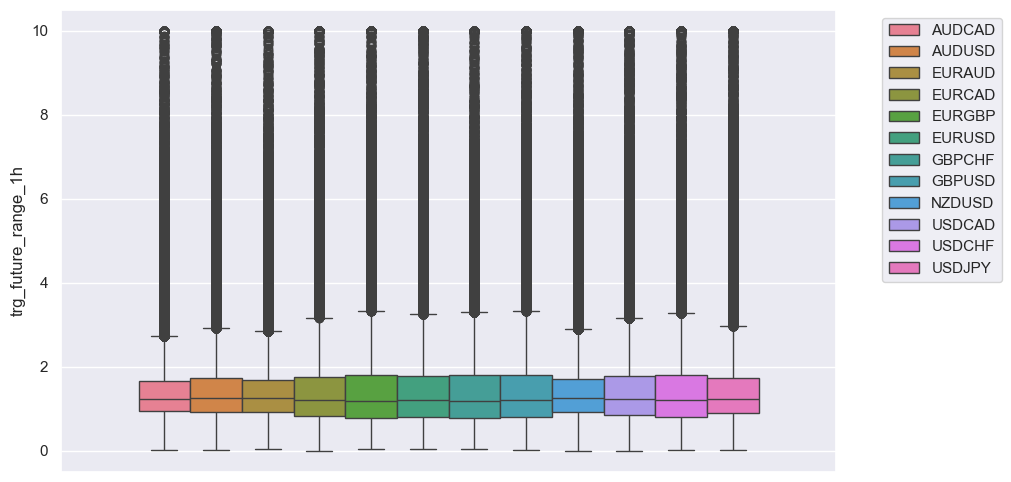

In [53]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=prices.drop_duplicates().dropna(), y='trg_future_range_1h', hue='instrument')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

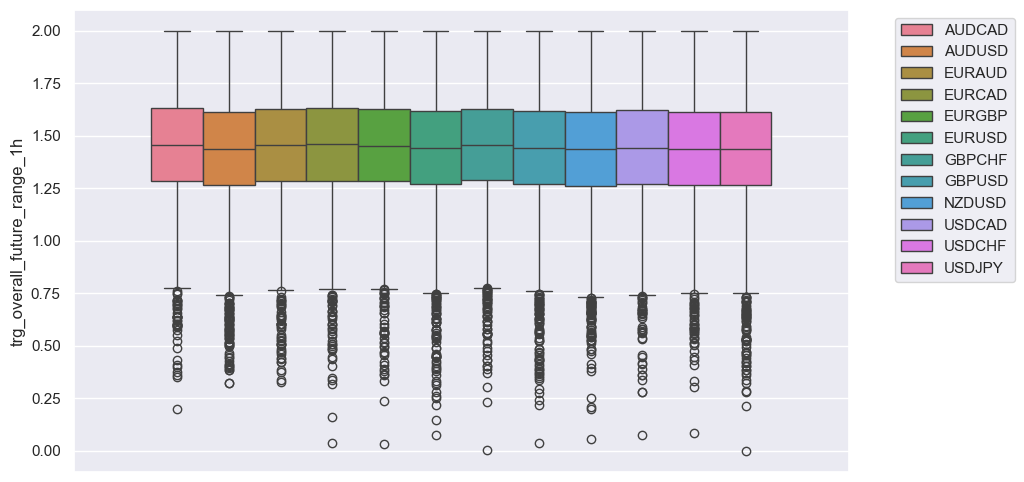

In [93]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=prices.drop_duplicates().dropna(), y='trg_overall_future_range_1h', hue='instrument', log_scale=False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

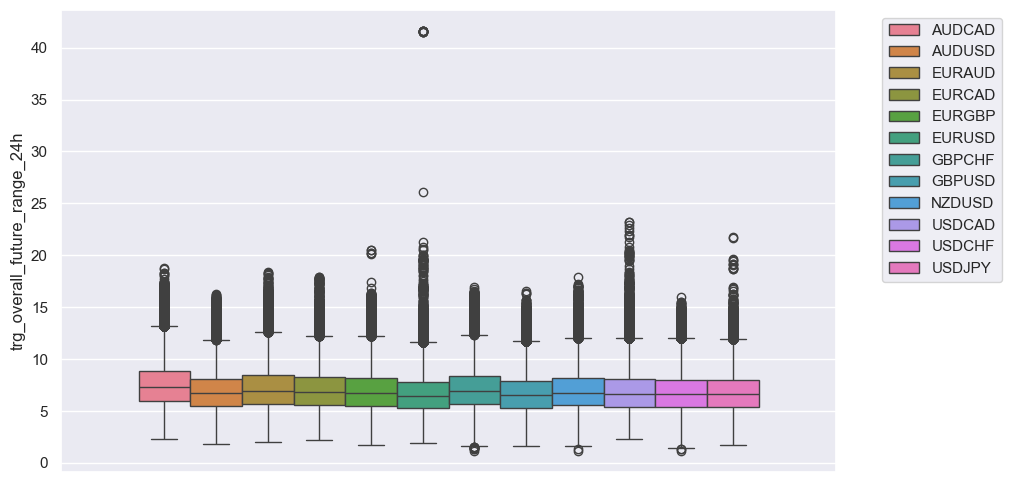

In [57]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=prices.drop_duplicates().dropna(), y='trg_overall_future_range_24h', hue='instrument', log_scale=False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

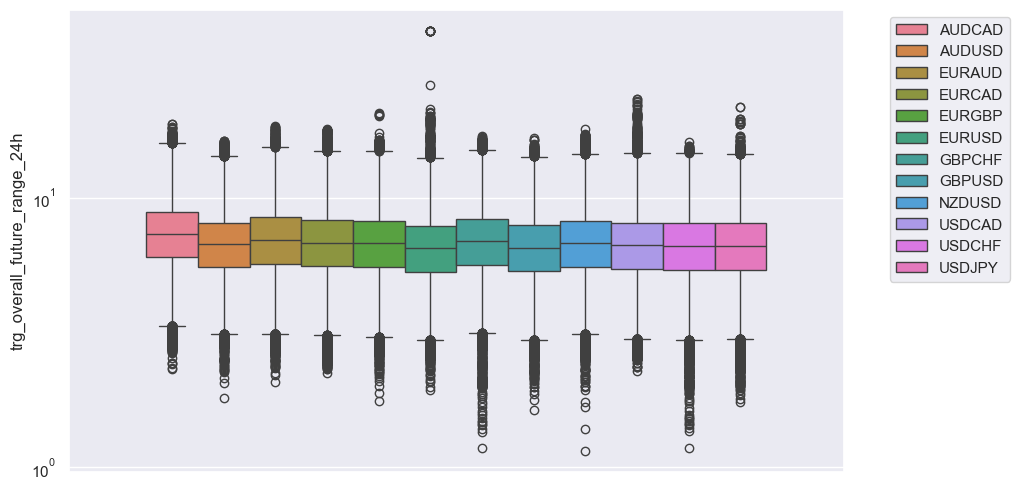

In [58]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=prices.drop_duplicates().dropna(), y='trg_overall_future_range_24h', hue='instrument', log_scale=True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

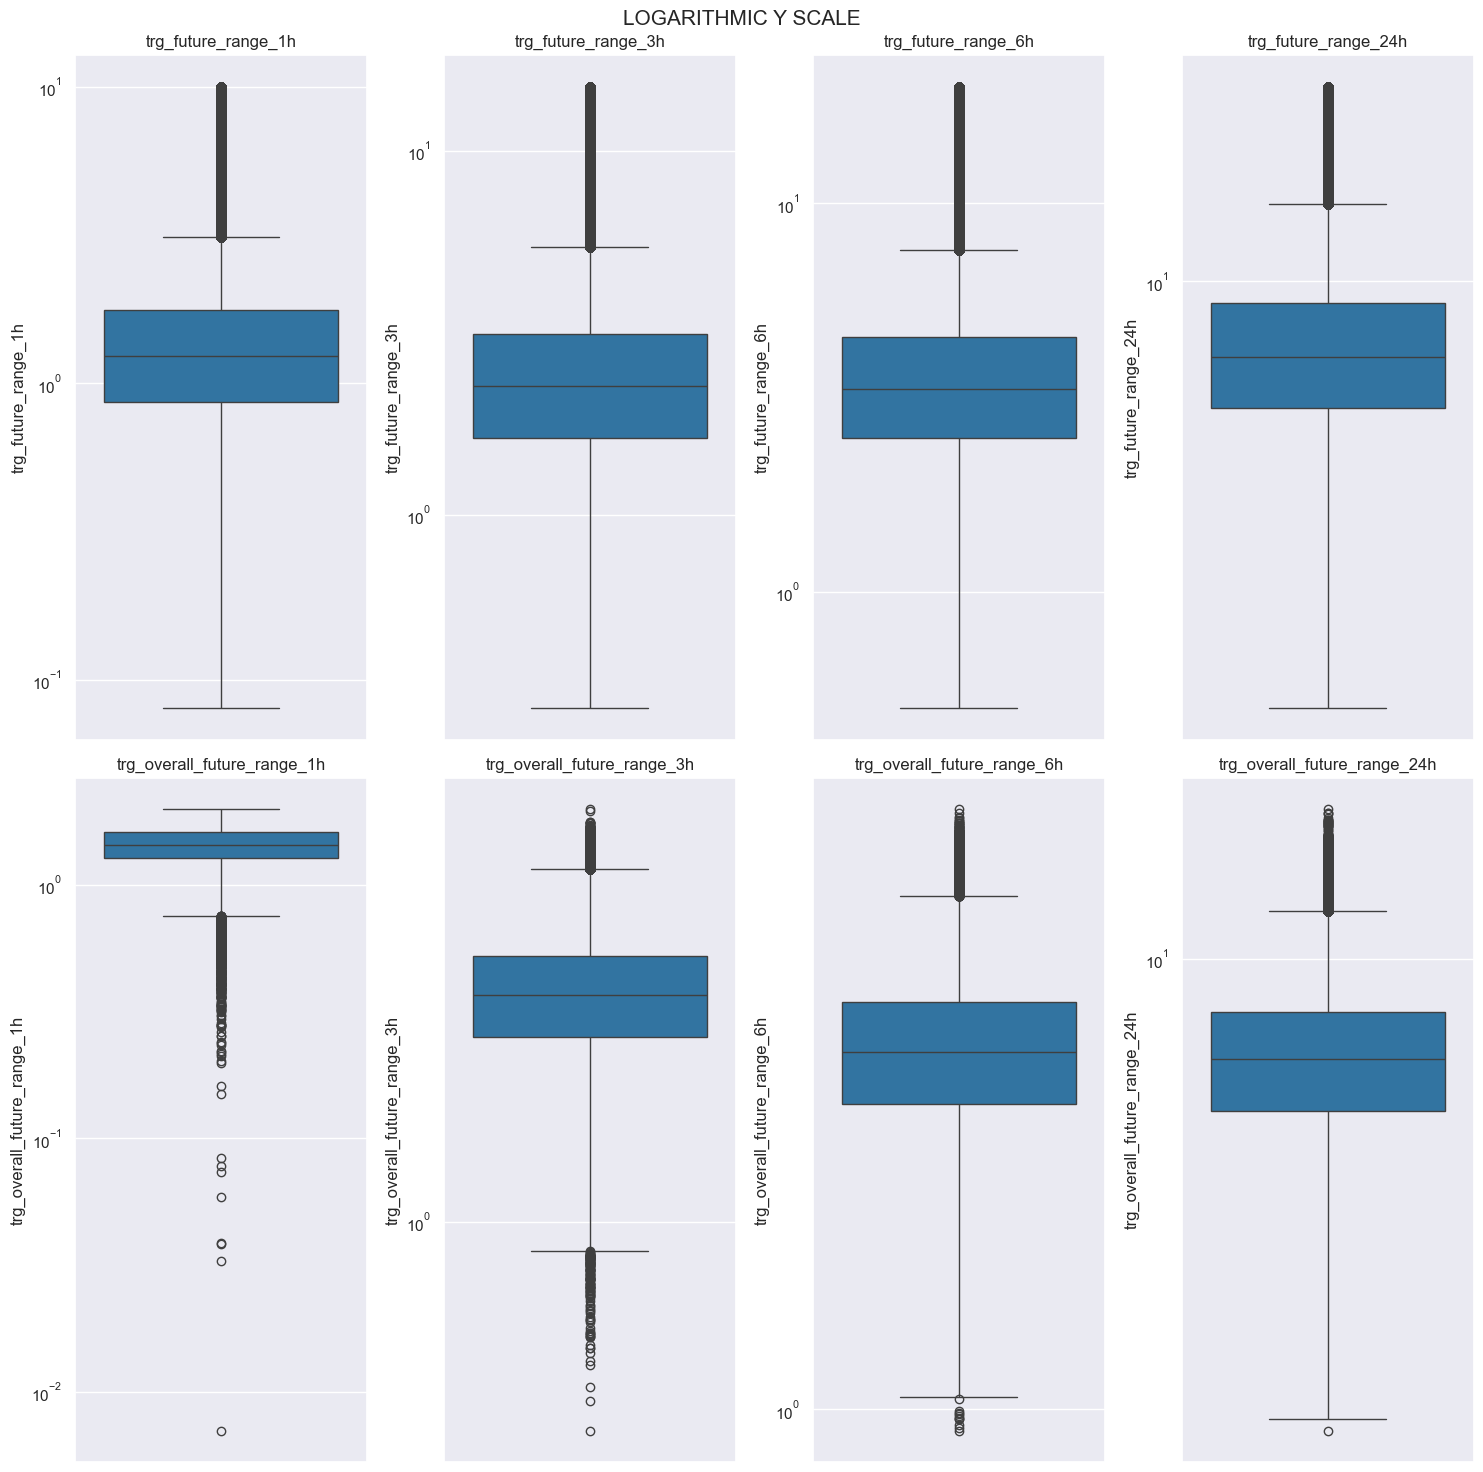

In [94]:
fig, axes = plt.subplots(2, 4, figsize=(15, 15))
fig. suptitle("LOGARITHMIC Y SCALE", fontsize=15)
axes = axes.flatten()
targets = [
    'trg_future_range_1h',
    'trg_future_range_3h',
    'trg_future_range_6h',
    'trg_future_range_24h',
    'trg_overall_future_range_1h',
    'trg_overall_future_range_3h',
    'trg_overall_future_range_6h',
    'trg_overall_future_range_24h'
]
for ax, col in zip(axes, targets):
    sns.boxplot(data=prices.drop_duplicates().dropna(), y=col, ax=ax)
    ax.set_yscale('log')
    ax.set_title(col)
plt.tight_layout()


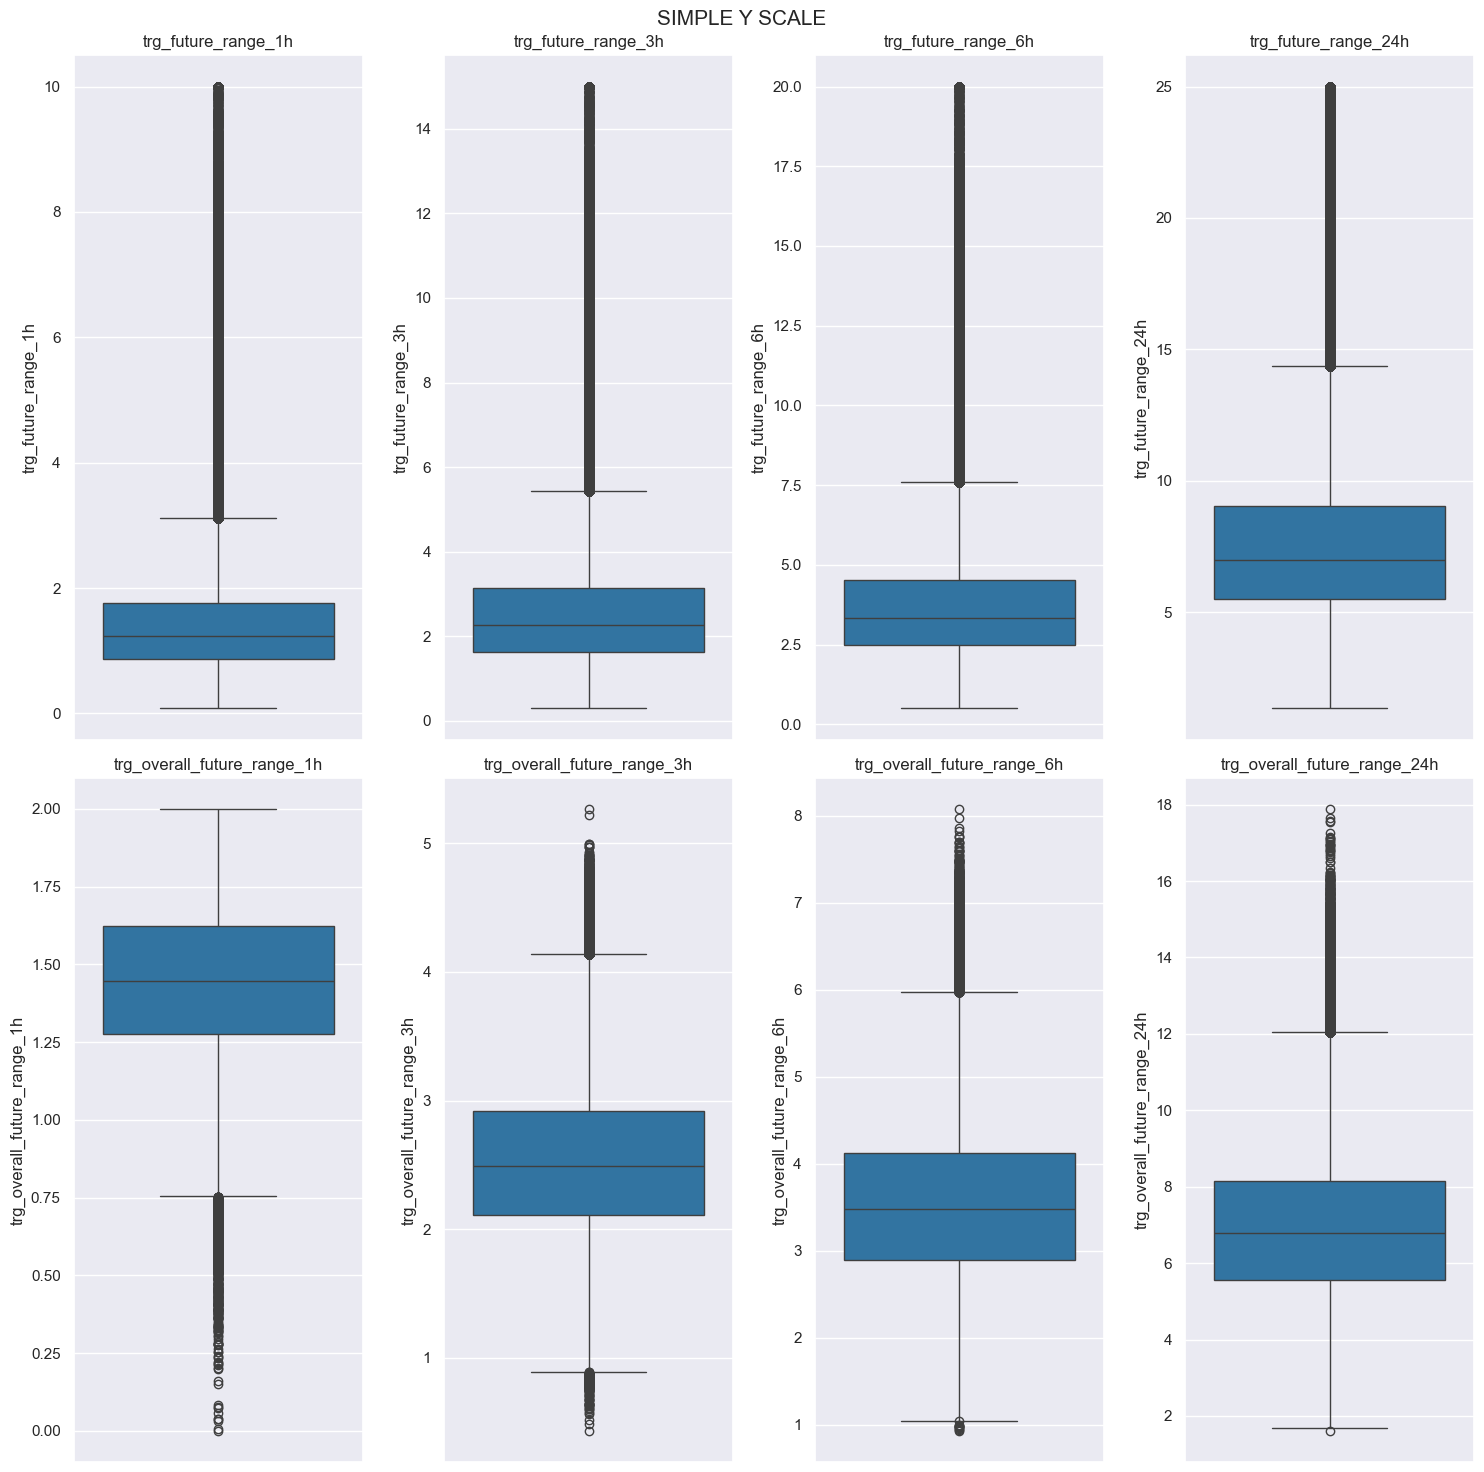

In [95]:
fig, axes = plt.subplots(2, 4, figsize=(15, 15))
fig. suptitle("SIMPLE Y SCALE", fontsize=15)
axes = axes.flatten()
targets = [
    'trg_future_range_1h',
    'trg_future_range_3h',
    'trg_future_range_6h',
    'trg_future_range_24h',
    'trg_overall_future_range_1h',
    'trg_overall_future_range_3h',
    'trg_overall_future_range_6h',
    'trg_overall_future_range_24h'
]
for ax, col in zip(axes, targets):
    sns.boxplot(data=prices.drop_duplicates().dropna(), y=col, ax=ax)
    # ax.set_yscale('log')
    ax.set_title(col)
plt.tight_layout()

## Add log features

In [38]:
for trg in tqdm(['trg_future_range_1h', 'trg_future_range_3h', 'trg_future_range_6h', 'trg_future_range_24h']):
    prices[trg + '_log'] = prices[trg].apply(lambda x: np.log1p(x))

100%|██████████| 4/4 [00:04<00:00,  1.14s/it]


100%|██████████| 4/4 [00:15<00:00,  3.80s/it]


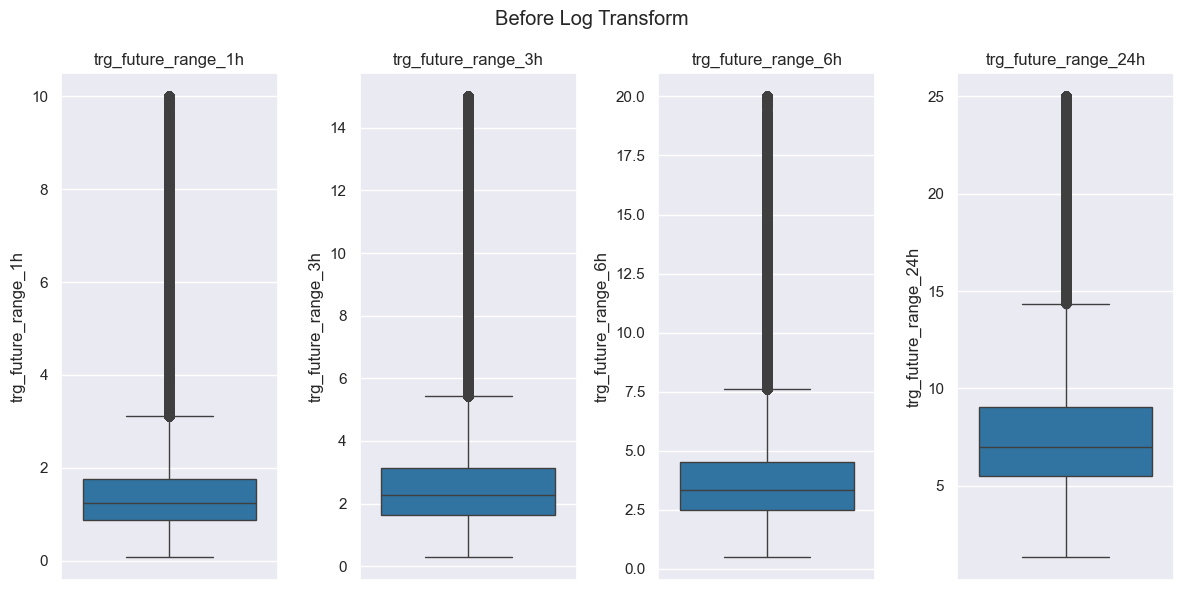

In [97]:
fig, axes = plt.subplots(1, 4, figsize=(12, 6))
fig.suptitle('Before Log Transform')
axes = axes.flatten()
targets = [
    'trg_future_range_1h',
    'trg_future_range_3h',
    'trg_future_range_6h',
    'trg_future_range_24h'
]
for ax, col in tqdm(zip(axes, targets), total=len(targets)):
    sns.boxplot(data=prices.drop_duplicates().dropna(), y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()

100%|██████████| 4/4 [00:14<00:00,  3.65s/it]


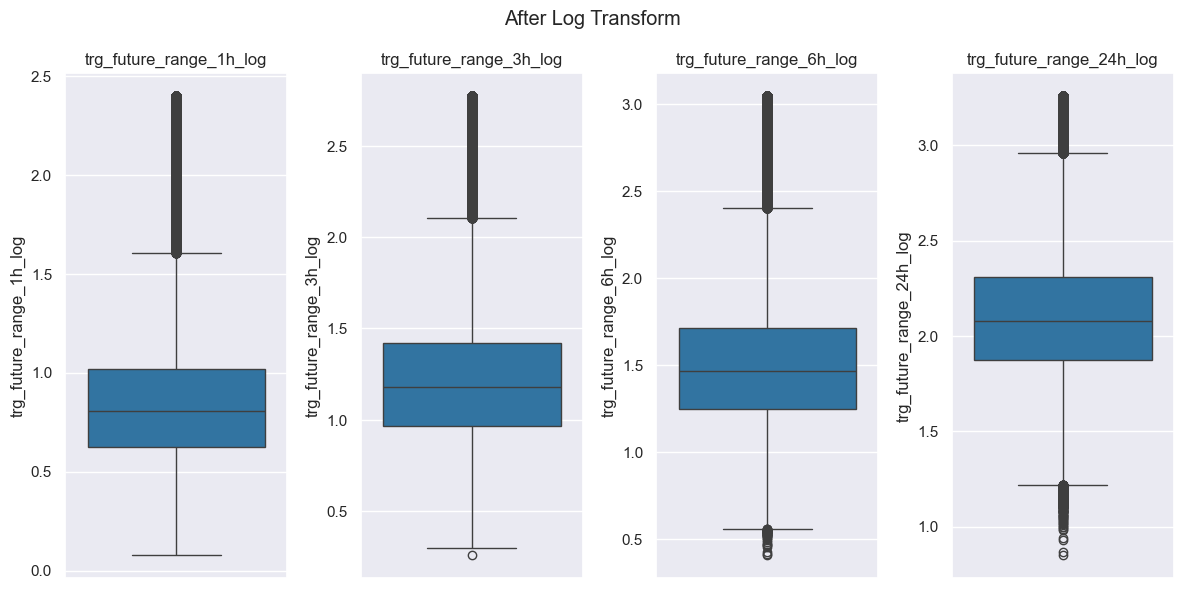

In [98]:
fig, axes = plt.subplots(1, 4, figsize=(12, 6))
fig.suptitle('After Log Transform')
axes = axes.flatten()
targets = [
    'trg_future_range_1h_log',
    'trg_future_range_3h_log',
    'trg_future_range_6h_log',
    'trg_future_range_24h_log'
]
for ax, col in tqdm(zip(axes, targets), total=len(targets)):
    sns.boxplot(data=prices.drop_duplicates().dropna(), y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()

## Join prices to events

In [31]:
agg_events.shape

(33564, 84)

In [32]:
prices.shape

(1188000, 53)

In [39]:
df = agg_events.merge(prices, left_on='time_to_check', right_on='time', how='left')

In [40]:
df.shape

(389410, 137)

In [42]:
df

,rounded_time,news_count,high_impact_count,key_event_count,main_event,prev_hour_news_count,next_hour_news_count,prev_hour_high_impact_count,next_hour_high_impact_count,prev_hour_main_event,next_hour_main_event,category_bnd,category_bsnss,category_cnsm,category_enrg,category_gdp,category_gov,category_hse,category_lbr,category_mny,category_mrkt,category_prce,category_trd,currency_AUD,currency_CAD,currency_EUR,currency_GBP,currency_JPY,currency_SEK,currency_SGD,currency_USD,country_AU,country_CA,country_DE,country_EU,country_FR,country_GB,country_JP,country_SE,country_SG,country_US,source_CENTRAL_BANK,source_ENERGY,source_GOV_MINISTRY,source_INDUSTRY,source_OFFICES,source_OFFICIAL_STATS,source_PRIVATE_SURVEY,source_RATING_AGENCY,source_RESEARCH_INSTITUTES,source_US_HOUSING,event_MONETARY_POLICY,event_CB_SPEECH,event_INFLATION,event_LABOR_MARKET,event_ECONOMIC_ACTIVITY,event_SENTIMENT,event_CONSUMER_HOUSING,event_TRADE_FINANCE,event_COMMODITIES,stage_release_Final,stage_release_Flash,stage_release_Preliminary,calc_period_MoM,calc_period_QoQ,calc_period_YoY,is_calendar,is_president,mie_Balance_of_Trade,mie_Core_Inflation_rate,mie_FOMC,mie_GDP,mie_Inflation_rate,mie_Interest_Rate_Decision,mie_NFP,mie_PMI,mie_PMI_Manufacturing,mie_PMI_Services,mie_Retail_Sales,mie_Unemployment_rate,time_passed_from_last_events,time_left_to_next_events,last_important_event_in_hours,time_to_check,time,instrument,base_currency,quote_currency,daily_atr,trange,atr,kaufman_efficiency_ratio,custom_efficiency_ratio,wick_ratio,relative_range,relative_atr,normalized_bb_width,distance_from_sma,ADX_21,ADXR_21_2,DMP_21,DMN_21,di_spread,tr_over_atr,realized_vol_ratio,parkinson_vol,parkinson_vol_over_atr,atr_short_over_long,abs_log_return_sum,vvov,week,month,quarter,dayofweek,day,hour,log_return,trg_future_range_1h,trg_future_range_3h,trg_future_range_6h,trg_future_range_24h,trg_overall_future_range_1h,trg_overall_future_range_3h,trg_overall_future_range_6h,trg_overall_future_range_24h,trg_big_doji,trg_dir_changes,trg_is_flat_flg,trg_is_trend_flg,trg_is_chaos_1h,trg_is_chaos_3h,trg_is_chaos_6h,trg_is_chaos_24h,trg_future_range_1h_log,trg_future_range_3h_log,trg_future_range_6h_log,trg_future_range_24h_log
0,2013-01-04 13:00:00+00:00,2,1,2,NFP,0.0,1.0,0.0,0.0,None,Inflation_rate,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,0,1,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0.0,96.0,NaN,2013-01-04 12:00:00+00:00,2013-01-04 12:00:00+00:00,AUDCAD,AUD,CAD,0.005046,0.00158,0.001374,0.166421,4.201550,1.329114e-01,0.132875,-0.333868,6.797432,2.028329,14.055974,13.829393,0.004277,0.006419,-0.002143,1.149523,1.031834,0.000795,0.578545,0.965506,0.004959,0.027104,1,1.0,1.0,4.0,4.0,12.0,0.000233,3.077522,3.077522,5.813098,6.053188,1.231387,2.609312,2.464022,6.878981,0.0,2.0,0.0,1.0,False,False,False,False,1.405490,1.405490,1.918847,1.953480
1,2013-01-04 13:00:00+00:00,2,1,2,NFP,0.0,1.0,0.0,0.0,None,Inflation_rate,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,0,1,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0.0,96.0,NaN,2013-01-04 12:00:00+00:00,2013-01-04 12:00:00+00:00,AUDUSD,AUD,USD,0.006179,0.00130,0.001412,0.387289,2.274849,1.769231e-01,-0.126985,0.262886,14.454087,3.104391,27.397533,26.649058,0.004138,0.010544,-0.006406,0.920822,0.930842,0.000949,0.671895,1.033959,0.006607,0.029326,1,1.0,1.0,4.0,4.0,12.0,-0.000221,3.222881,4.660782,7.805747,8.131577,1.094265,1.805197,1.836494,5.614494,0.0,1.0,0.0,1.0,False,False,False,False,1.440518,1.733562,2.175405,2.211738
2,2013-01-04 13:00:00+00:00,2,1,2,NFP,0.0,1.0,0.0,0.0,None,Inflation_rate,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,0,1,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0.0,96.0,NaN,2013-01-04 12:00:00+00:00,2013-01-04 12:00:00+00:00,EURAUD,EUR,AUD,0.008361,0.00258,0.001968,0.127218,5.010944,3.875969e-02,0.457941,-0.313728,4.208374,9.213276,49.129315,50.556672,0.006067,0.008894,-0.002827,1.31

In [44]:
df['main_event'].isna().sum()

np.int64(0)

In [43]:
df['main_event'].value_counts()

main_event
No main events            264434
Inflation_rate             28114
PMI_Manufacturing          15993
Retail_Sales               11401
Balance_of_Trade           11323
PMI                        11050
GDP                        10974
Unemployment_rate          10706
PMI_Services                9054
Interest_Rate_Decision      7669
Core_Inflation_rate         5452
NFP                         1752
FOMC                        1488
Name: count, dtype: int64

In [45]:
def add_lagged_target_features(df, windows=[5, 20]):
    """
    Adds lagged target features for news titles and categories to capture regime shifts.
    """
    # We need to sort by date to avoid leakage
    df = df.sort_values('time_to_check')
    
    # Collect new columns in a dict to concat once per horizon
    new_cols = {}
    
    # 1. Last N events of the same dominant_event_type
    for h in tqdm([1, 3, 6, 24]):
        col = f'trg_future_range_{h}h_log'
        for w in windows:
            new_cols[f'prev5_avg_{h}h_{w}'] = (
                df.groupby(['main_event', 'instrument'])[col]
                .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).mean())
            ).fillna(0)
            new_cols[f'prev5_min_{h}h_{w}'] = (
                df.groupby(['main_event', 'instrument'])[col]
                .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).min())
            ).fillna(0)
            new_cols[f'prev5_max_{h}h_{w}'] = (
                df.groupby(['main_event', 'instrument'])[col]
                .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).max())
            ).fillna(0)
        
        new_cols[f'prev_{h}h'] = (
            df.groupby(['main_event', 'instrument'])[col]
            .transform(lambda x: x.shift(1))
        ).fillna(0)
    
        # 2. Overall recent volatility (last 50 news events)
        # Captures the general market regime independent of the news type
        new_cols[f'lag_target_overall_50_{h}h'] = df[col].shift(1).rolling(50, min_periods=1).mean().fillna(0)
    
    # Concatenate all new columns at once
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    return df

In [46]:
df = add_lagged_target_features(df)

100%|██████████| 4/4 [00:03<00:00,  1.18it/s]


In [47]:
df

,rounded_time,news_count,high_impact_count,key_event_count,main_event,prev_hour_news_count,next_hour_news_count,prev_hour_high_impact_count,next_hour_high_impact_count,prev_hour_main_event,next_hour_main_event,category_bnd,category_bsnss,category_cnsm,category_enrg,category_gdp,category_gov,category_hse,category_lbr,category_mny,category_mrkt,category_prce,category_trd,currency_AUD,currency_CAD,currency_EUR,currency_GBP,currency_JPY,currency_SEK,currency_SGD,currency_USD,country_AU,country_CA,country_DE,country_EU,country_FR,country_GB,country_JP,country_SE,country_SG,country_US,source_CENTRAL_BANK,source_ENERGY,source_GOV_MINISTRY,source_INDUSTRY,source_OFFICES,source_OFFICIAL_STATS,source_PRIVATE_SURVEY,source_RATING_AGENCY,source_RESEARCH_INSTITUTES,source_US_HOUSING,event_MONETARY_POLICY,event_CB_SPEECH,event_INFLATION,event_LABOR_MARKET,event_ECONOMIC_ACTIVITY,event_SENTIMENT,event_CONSUMER_HOUSING,event_TRADE_FINANCE,event_COMMODITIES,stage_release_Final,stage_release_Flash,stage_release_Preliminary,calc_period_MoM,calc_period_QoQ,calc_period_YoY,is_calendar,is_president,mie_Balance_of_Trade,mie_Core_Inflation_rate,mie_FOMC,mie_GDP,mie_Inflation_rate,mie_Interest_Rate_Decision,mie_NFP,mie_PMI,mie_PMI_Manufacturing,mie_PMI_Services,mie_Retail_Sales,mie_Unemployment_rate,time_passed_from_last_events,time_left_to_next_events,last_important_event_in_hours,time_to_check,time,instrument,base_currency,quote_currency,daily_atr,trange,atr,kaufman_efficiency_ratio,custom_efficiency_ratio,wick_ratio,relative_range,relative_atr,normalized_bb_width,distance_from_sma,ADX_21,ADXR_21_2,DMP_21,DMN_21,di_spread,tr_over_atr,realized_vol_ratio,parkinson_vol,parkinson_vol_over_atr,atr_short_over_long,abs_log_return_sum,vvov,week,month,quarter,dayofweek,day,hour,log_return,trg_future_range_1h,trg_future_range_3h,trg_future_range_6h,trg_future_range_24h,trg_overall_future_range_1h,trg_overall_future_range_3h,trg_overall_future_range_6h,trg_overall_future_range_24h,trg_big_doji,trg_dir_changes,trg_is_flat_flg,trg_is_trend_flg,trg_is_chaos_1h,trg_is_chaos_3h,trg_is_chaos_6h,trg_is_chaos_24h,trg_future_range_1h_log,trg_future_range_3h_log,trg_future_range_6h_log,trg_future_range_24h_log,prev5_avg_1h_5,prev5_min_1h_5,prev5_max_1h_5,prev5_avg_1h_20,prev5_min_1h_20,prev5_max_1h_20,prev_1h,lag_target_overall_50_1h,prev5_avg_3h_5,prev5_min_3h_5,prev5_max_3h_5,prev5_avg_3h_20,prev5_min_3h_20,prev5_max_3h_20,prev_3h,lag_target_overall_50_3h,prev5_avg_6h_5,prev5_min_6h_5,prev5_max_6h_5,prev5_avg_6h_20,prev5_min_6h_20,prev5_max_6h_20,prev_6h,lag_target_overall_50_6h,prev5_avg_24h_5,prev5_min_24h_5,prev5_max_24h_5,prev5_avg_24h_20,prev5_min_24h_20,prev5_max_24h_20,prev_24h,lag_target_overall_50_24h
0,2013-01-04 13:00:00+00:00,2,1,2,NFP,0.0,1.0,0.0,0.0,None,Inflation_rate,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,0,1,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0.0,96.0,NaN,2013-01-04 12:00:00+00:00,2013-01-04 12:00:00+00:00,AUDCAD,AUD,CAD,0.005046,0.00158,0.001374,0.166421,4.201550,0.132911,0.132875,-0.333868,6.797432,2.028329,14.055974,13.829393,0.004277,0.006419,-0.002143,1.149523,1.031834,0.000795,0.578545,0.965506,0.004959,0.027104,1,1.0,1.0,4.0,4.0,12.0,0.000233,3.077522,3.077522,5.813098,6.053188,1.231387,2.609312,2.464022,6.878981,0.0,2.0,0.0,1.0,False,False,False,False,1.405490,1.405490,1.918847,1.953480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11,2013-01-04 13:00:00+00:00,2,1,2,NFP,0.0,1.0,0.0,0.0,None,Inflation_rate,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,0,1,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0.0,96.0,NaN,2013-01-04 12:00:00+00:00,2013-01-04 12:00:00+00:00,USDJPY,USD,JPY,0.614801,0.09300,0.157854,0.

In [74]:
for ftr in ['trg_big_doji', 'trg_dir_changes', 'trg_is_flat_flg', 'trg_is_trend_flg']:
    df[ftr] = df[ftr].fillna(0).astype(int)

In [75]:
df.head()

,rounded_time,news_count,high_impact_count,key_event_count,main_event,prev_hour_news_count,next_hour_news_count,prev_hour_high_impact_count,next_hour_high_impact_count,prev_hour_main_event,next_hour_main_event,category_bnd,category_bsnss,category_cnsm,category_enrg,category_gdp,category_gov,category_hse,category_lbr,category_mny,category_mrkt,category_prce,category_trd,currency_AUD,currency_CAD,currency_EUR,currency_GBP,currency_JPY,currency_SEK,currency_SGD,currency_USD,country_AU,country_CA,country_DE,country_EU,country_FR,country_GB,country_JP,country_SE,country_SG,country_US,source_CENTRAL_BANK,source_ENERGY,source_GOV_MINISTRY,source_INDUSTRY,source_OFFICES,source_OFFICIAL_STATS,source_PRIVATE_SURVEY,source_RATING_AGENCY,source_RESEARCH_INSTITUTES,source_US_HOUSING,event_MONETARY_POLICY,event_CB_SPEECH,event_INFLATION,event_LABOR_MARKET,event_ECONOMIC_ACTIVITY,event_SENTIMENT,event_CONSUMER_HOUSING,event_TRADE_FINANCE,event_COMMODITIES,stage_release_Final,stage_release_Flash,stage_release_Preliminary,calc_period_MoM,calc_period_QoQ,calc_period_YoY,is_calendar,is_president,mie_Balance_of_Trade,mie_Core_Inflation_rate,mie_FOMC,mie_GDP,mie_Inflation_rate,mie_Interest_Rate_Decision,mie_NFP,mie_PMI,mie_PMI_Manufacturing,mie_PMI_Services,mie_Retail_Sales,mie_Unemployment_rate,time_passed_from_last_events,time_left_to_next_events,last_important_event_in_hours,time_to_check,time,instrument,base_currency,quote_currency,daily_atr,trange,atr,kaufman_efficiency_ratio,custom_efficiency_ratio,wick_ratio,relative_range,relative_atr,normalized_bb_width,distance_from_sma,ADX_21,ADXR_21_2,DMP_21,DMN_21,di_spread,tr_over_atr,realized_vol_ratio,parkinson_vol,parkinson_vol_over_atr,atr_short_over_long,abs_log_return_sum,vvov,week,month,quarter,dayofweek,day,hour,log_return,trg_future_range_1h,trg_future_range_3h,trg_future_range_6h,trg_future_range_24h,trg_overall_future_range_1h,trg_overall_future_range_3h,trg_overall_future_range_6h,trg_overall_future_range_24h,trg_big_doji,trg_dir_changes,trg_is_flat_flg,trg_is_trend_flg,trg_is_chaos_1h,trg_is_chaos_3h,trg_is_chaos_6h,trg_is_chaos_24h,trg_future_range_1h_log,trg_future_range_3h_log,trg_future_range_6h_log,trg_future_range_24h_log,prev5_avg_1h_5,prev5_min_1h_5,prev5_max_1h_5,prev5_avg_1h_20,prev5_min_1h_20,prev5_max_1h_20,prev_1h,lag_target_overall_50_1h,prev5_avg_3h_5,prev5_min_3h_5,prev5_max_3h_5,prev5_avg_3h_20,prev5_min_3h_20,prev5_max_3h_20,prev_3h,lag_target_overall_50_3h,prev5_avg_6h_5,prev5_min_6h_5,prev5_max_6h_5,prev5_avg_6h_20,prev5_min_6h_20,prev5_max_6h_20,prev_6h,lag_target_overall_50_6h,prev5_avg_24h_5,prev5_min_24h_5,prev5_max_24h_5,prev5_avg_24h_20,prev5_min_24h_20,prev5_max_24h_20,prev_24h,lag_target_overall_50_24h
0,2013-01-04 13:00:00+00:00,2,1,2,NFP,0.0,1.0,0.0,0.0,None,Inflation_rate,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,0,1,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0.0,96.0,NaN,2013-01-04 12:00:00+00:00,2013-01-04 12:00:00+00:00,AUDCAD,AUD,CAD,0.005046,0.00158,0.001374,0.166421,4.201550,0.132911,0.132875,-0.333868,6.797432,2.028329,14.055974,13.829393,0.004277,0.006419,-0.002143,1.149523,1.031834,0.000795,0.578545,0.965506,0.004959,0.027104,1,1.0,1.0,4.0,4.0,12.0,0.000233,3.077522,3.077522,5.813098,6.053188,1.231387,2.609312,2.464022,6.878981,0,2,0,1,False,False,False,False,1.405490,1.405490,1.918847,1.953480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
11,2013-01-04 13:00:00+00:00,2,1,2,NFP,0.0,1.0,0.0,0.0,None,Inflation_rate,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,0,1,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0.0,96.0,NaN,2013-01-04 12:00:00+00:00,2013-01-04 12:00:00+00:00,USDJPY,USD,JPY,0.614801,0.09300,0.157854,0.361219,2.382838,0.139785,-0.669817,0.949123,17.107682,20.580434,39.638943,38.252693,1.299465,0.254437,1.045027,0.589152,1.202590,0.001342,0.008502,1

In [76]:
df.shape

(389410, 169)

In [77]:
df.isna().sum().sort_values(ascending=False)

wick_ratio                   1215
trg_future_range_1h_log      1208
trg_future_range_3h_log      1208
trg_future_range_6h_log      1208
trg_future_range_24h_log     1208
                             ... 
prev5_avg_24h_20                0
prev5_min_24h_20                0
prev5_max_24h_20                0
prev_24h                        0
lag_target_overall_50_24h       0
Length: 169, dtype: int64

In [78]:
trg_columns = [c for c in df.columns if c.startswith('trg_')]
df.dropna(subset=trg_columns+['wick_ratio'], inplace=True)

In [79]:
df.isna().sum().sort_values(ascending=False)

prev_hour_main_event             12
next_hour_main_event             12
last_important_event_in_hours    12
news_count                        0
high_impact_count                 0
                                 ..
prev5_avg_24h_20                  0
prev5_min_24h_20                  0
prev5_max_24h_20                  0
prev_24h                          0
lag_target_overall_50_24h         0
Length: 169, dtype: int64

In [81]:
agg_events.head()

,rounded_time,news_count,high_impact_count,key_event_count,main_event,prev_hour_news_count,next_hour_news_count,prev_hour_high_impact_count,next_hour_high_impact_count,prev_hour_main_event,next_hour_main_event,category_bnd,category_bsnss,category_cnsm,category_enrg,category_gdp,category_gov,category_hse,category_lbr,category_mny,category_mrkt,category_prce,category_trd,currency_AUD,currency_CAD,currency_EUR,currency_GBP,currency_JPY,currency_SEK,currency_SGD,currency_USD,country_AU,country_CA,country_DE,country_EU,country_FR,country_GB,country_JP,country_SE,country_SG,country_US,source_CENTRAL_BANK,source_ENERGY,source_GOV_MINISTRY,source_INDUSTRY,source_OFFICES,source_OFFICIAL_STATS,source_PRIVATE_SURVEY,source_RATING_AGENCY,source_RESEARCH_INSTITUTES,source_US_HOUSING,event_MONETARY_POLICY,event_CB_SPEECH,event_INFLATION,event_LABOR_MARKET,event_ECONOMIC_ACTIVITY,event_SENTIMENT,event_CONSUMER_HOUSING,event_TRADE_FINANCE,event_COMMODITIES,stage_release_Final,stage_release_Flash,stage_release_Preliminary,calc_period_MoM,calc_period_QoQ,calc_period_YoY,is_calendar,is_president,mie_Balance_of_Trade,mie_Core_Inflation_rate,mie_FOMC,mie_GDP,mie_Inflation_rate,mie_Interest_Rate_Decision,mie_NFP,mie_PMI,mie_PMI_Manufacturing,mie_PMI_Services,mie_Retail_Sales,mie_Unemployment_rate,time_passed_from_last_events,time_left_to_next_events,last_important_event_in_hours,time_to_check
0,2013-01-04 13:00:00+00:00,2,1,2,NFP,0.0,1.0,0.0,0.0,None,Inflation_rate,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,0,1,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0.0,96.0,NaN,2013-01-04 12:00:00+00:00
1,2013-01-06 13:00:00+00:00,1,0,1,Inflation_rate,2.0,5.0,1.0,0.0,NFP,Retail_Sales,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,96.0,520.0,48.0,2013-01-06 12:00:00+00:00
2,2013-01-17 09:00:00+00:00,5,0,5,Retail_Sales,1.0,27.0,0.0,0.0,Inflation_rate,Unemployment_rate,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,10,0,0,0,0,0,2,0,3,0,0,0,0,0,0,0,0,0,0,0,0,5,0,520.0,288.0,260.0,2013-01-17 08:00:00+00:00
3,2013-01-23 09:00:00+00:00,27,0,1,Unemployment_rate,5.0,1.0,0.0,0.0,Retail_Sales,No main events,0,2,0,0,0,11,0,1,13,0,0,0,0,0,10,3,0,4,0,10,0,0,0,10,0,3,0,4,0,10,13,0,0,0,0,1,0,0,0,0,15,16,0,2,0,0,2,2,0,0,0,0,0,0,0,7,1,0,0,0,0,0,0,0,0,0,0,0,1,288.0,104.0,144.0,2013-01-23 08:00:00+00:00
4,2013-01-25 13:00:00+00:00,1,0,0,No main events,27.0,1.0,0.0,0.0,Unemployment_rate,No main events,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,104.0,170.0,52.0,2013-01-25 12:00:00+00:00


In [80]:
df.dropna(subset=['last_important_event_in_hours', 'prev_hour_main_event', 'next_hour_main_event'], inplace=True)

In [82]:
df.shape

(388171, 169)

# Train CatBoost Model

## Train Future Range model

In [ ]:
from training_functions import (run_time_series_cv_catboost_quantile, run_time_series_cv_catboost, run_time_series_cv_catboost_quantile_gpu)

In [34]:
FEATURES = [i for i in df.columns if not i.startswith('trg') and i not in ['time', 'time_to_check', 'rounded_time']]
CATEGORICAL_FEATURES = ['main_event', 'instrument', 'base_currency', 'quote_currency', 'prev_hour_main_event', 'next_hour_main_event']

In [35]:
df[CATEGORICAL_FEATURES] = df[CATEGORICAL_FEATURES].fillna("missing").astype(str)

In [35]:
for cat_feat in CATEGORICAL_FEATURES:
    df[cat_feat] = df[cat_feat].astype('category')

In [39]:
DESC = f"""
- One hot classes: {[i for i in df.columns if i.startswith('category')]}
- One hot events: {[i for i in df.columns if i.startswith('event')]}
- One hot sources: {[i for i in df.columns if i.startswith('source')]}
- Main aggregations: {['news_count', 'high_impact_count', 'key_event_count', 'main_event']}
- Currency: {[i for i in df.columns if i.startswith('currency')]}
"""
print(DESC)


- One hot classes: ['category_bnd', 'category_bsnss', 'category_cnsm', 'category_enrg', 'category_gdp', 'category_gov', 'category_hse', 'category_lbr', 'category_mny', 'category_mrkt', 'category_prce', 'category_trd']
- One hot events: ['event_MONETARY_POLICY', 'event_CB_SPEECH', 'event_INFLATION', 'event_LABOR_MARKET', 'event_ECONOMIC_ACTIVITY', 'event_SENTIMENT', 'event_CONSUMER_HOUSING', 'event_TRADE_FINANCE', 'event_COMMODITIES']
- One hot sources: ['source_CENTRAL_BANK', 'source_ENERGY', 'source_GOV_MINISTRY', 'source_INDUSTRY', 'source_OFFICES', 'source_OFFICIAL_STATS', 'source_PRIVATE_SURVEY', 'source_RATING_AGENCY', 'source_RESEARCH_INSTITUTES', 'source_US_HOUSING']
- Main aggregations: ['news_count', 'high_impact_count', 'key_event_count', 'main_event']
- Currency: ['currency_AUD', 'currency_CAD', 'currency_EUR', 'currency_GBP', 'currency_JPY', 'currency_SEK', 'currency_SGD', 'currency_USD']



In [41]:
metrics = run_time_series_cv_catboost_quantile_gpu(
    df=df,
    features=FEATURES,
    cat_features=CATEGORICAL_FEATURES,
    target='trg_future_range_1h_log',
    time_col='time_to_check',
    quantiles=[0.1, 0.5, 0.9],
    experiment_name='Final Pipe: Future Range Prediction (1H) QoQ (Log)',
    run_name='future_range_1h_5k_iter',
    description=DESC
)

[INFO] FOLD: 1
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-01-17 08:30:00+00:00
[INFO] Min val date: 2025-01-23 03:00:00+00:00
[INFO] Max val date: 2025-04-17 03:00:00+00:00
[INFO] Train count: 48276
[INFO] Val count: 972
[INFO] FOLD: 2
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-04-17 03:00:00+00:00
[INFO] Min val date: 2025-04-22 07:30:00+00:00
[INFO] Max val date: 2025-07-14 04:00:00+00:00
[INFO] Train count: 49248
[INFO] Val count: 840
[INFO] FOLD: 3
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-07-14 04:00:00+00:00
[INFO] Min val date: 2025-07-18 03:00:00+00:00
[INFO] Max val date: 2025-10-17 06:00:00+00:00
[INFO] Train count: 50088
[INFO] Val count: 948
[INFO] FOLD: 4
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-10-17 06:00:00+00:00
[INFO] Min val date: 2025-10-23 22:30:00+00:00
[INFO] Max val date: 2026-01-16 03:00:00+00:00
[INFO] Train count: 51036
[I

In [43]:
metrics = run_time_series_cv_catboost_quantile_gpu(
    df=df,
    features=FEATURES,
    cat_features=CATEGORICAL_FEATURES,
    target='trg_future_range_3h_log',
    time_col='time_to_check',
    quantiles=[0.1, 0.5, 0.9],
    experiment_name='Final Pipe: Future Range Prediction (3H) QoQ (Log)',
    run_name='future_range_3h_5k_iter',
    description=DESC
)

[INFO] FOLD: 1
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-01-17 08:30:00+00:00
[INFO] Min val date: 2025-01-23 03:00:00+00:00
[INFO] Max val date: 2025-04-17 03:00:00+00:00
[INFO] Train count: 48276
[INFO] Val count: 972
[INFO] FOLD: 2
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-04-17 03:00:00+00:00
[INFO] Min val date: 2025-04-22 07:30:00+00:00
[INFO] Max val date: 2025-07-14 04:00:00+00:00
[INFO] Train count: 49248
[INFO] Val count: 840
[INFO] FOLD: 3
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-07-14 04:00:00+00:00
[INFO] Min val date: 2025-07-18 03:00:00+00:00
[INFO] Max val date: 2025-10-17 06:00:00+00:00
[INFO] Train count: 50088
[INFO] Val count: 948
[INFO] FOLD: 4
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-10-17 06:00:00+00:00
[INFO] Min val date: 2025-10-23 22:30:00+00:00
[INFO] Max val date: 2026-01-16 03:00:00+00:00
[INFO] Train count: 51036
[I

In [44]:
metrics = run_time_series_cv_catboost_quantile_gpu(
    df=df,
    features=FEATURES,
    cat_features=CATEGORICAL_FEATURES,
    target='trg_future_range_6h_log',
    time_col='time_to_check',
    quantiles=[0.1, 0.5, 0.9],
    experiment_name='Final Pipe: Future Range Prediction (6H) QoQ (Log)',
    run_name='future_range_6h_5k_iter',
    description=DESC
)

2026/04/17 18:25:38 INFO mlflow.tracking.fluent: Experiment with name 'Final Pipe: Future Range Prediction (6H) QoQ (Log)' does not exist. Creating a new experiment.


[INFO] FOLD: 1
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-01-17 08:30:00+00:00
[INFO] Min val date: 2025-01-23 03:00:00+00:00
[INFO] Max val date: 2025-04-17 03:00:00+00:00
[INFO] Train count: 48276
[INFO] Val count: 972
[INFO] FOLD: 2
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-04-17 03:00:00+00:00
[INFO] Min val date: 2025-04-22 07:30:00+00:00
[INFO] Max val date: 2025-07-14 04:00:00+00:00
[INFO] Train count: 49248
[INFO] Val count: 840
[INFO] FOLD: 3
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-07-14 04:00:00+00:00
[INFO] Min val date: 2025-07-18 03:00:00+00:00
[INFO] Max val date: 2025-10-17 06:00:00+00:00
[INFO] Train count: 50088
[INFO] Val count: 948
[INFO] FOLD: 4
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-10-17 06:00:00+00:00
[INFO] Min val date: 2025-10-23 22:30:00+00:00
[INFO] Max val date: 2026-01-16 03:00:00+00:00
[INFO] Train count: 51036
[I

In [45]:
metrics = run_time_series_cv_catboost_quantile_gpu(
    df=df,
    features=FEATURES,
    cat_features=CATEGORICAL_FEATURES,
    target='trg_future_range_24h_log',
    time_col='time_to_check',
    quantiles=[0.1, 0.5, 0.9],
    experiment_name='Final Pipe: Future Range Prediction (24H) QoQ (Log)',
    run_name='future_range_24h_5k_iter',
    description=DESC
)

2026/04/17 18:28:49 INFO mlflow.tracking.fluent: Experiment with name 'Final Pipe: Future Range Prediction (24H) QoQ (Log)' does not exist. Creating a new experiment.


[INFO] FOLD: 1
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-01-17 08:30:00+00:00
[INFO] Min val date: 2025-01-23 03:00:00+00:00
[INFO] Max val date: 2025-04-17 03:00:00+00:00
[INFO] Train count: 48276
[INFO] Val count: 972
[INFO] FOLD: 2
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-04-17 03:00:00+00:00
[INFO] Min val date: 2025-04-22 07:30:00+00:00
[INFO] Max val date: 2025-07-14 04:00:00+00:00
[INFO] Train count: 49248
[INFO] Val count: 840
[INFO] FOLD: 3
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-07-14 04:00:00+00:00
[INFO] Min val date: 2025-07-18 03:00:00+00:00
[INFO] Max val date: 2025-10-17 06:00:00+00:00
[INFO] Train count: 50088
[INFO] Val count: 948
[INFO] FOLD: 4
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-10-17 06:00:00+00:00
[INFO] Min val date: 2025-10-23 22:30:00+00:00
[INFO] Max val date: 2026-01-16 03:00:00+00:00
[INFO] Train count: 51036
[I

In [ ]:
# metrics = run_time_series_cv_catboost_quantile(
#     df=df,
#     features=FEATURES,
#     cat_features=CATEGORICAL_FEATURES,
#     target='trg_future_range_6h_log',
#     time_col='time_to_check',
#     quantiles=[0.1, 0.5, 0.9],
#     experiment_name='Final Pipe: Future Range Prediction (6H) QoQ (Log)',
#     run_name='future_range_6h_5k_iter',
#     description=DESC
# )

2026/04/17 18:20:25 INFO mlflow.tracking.fluent: Experiment with name 'Final Pipe: Future Range Prediction (3H) QoQ (Log)' does not exist. Creating a new experiment.


[INFO] FOLD: 1
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-01-17 08:30:00+00:00
[INFO] Min val date: 2025-01-23 03:00:00+00:00
[INFO] Max val date: 2025-04-17 03:00:00+00:00
[INFO] Train count: 48276
[INFO] Val count: 972
[INFO] FOLD: 2
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-04-17 03:00:00+00:00
[INFO] Min val date: 2025-04-22 07:30:00+00:00
[INFO] Max val date: 2025-07-14 04:00:00+00:00
[INFO] Train count: 49248
[INFO] Val count: 840


In [ ]:
# metrics = run_time_series_cv_catboost_quantile(
#     df=df,
#     features=FEATURES,
#     cat_features=CATEGORICAL_FEATURES,
#     target='trg_future_range_24h_log',
#     time_col='time_to_check',
#     quantiles=[0.1, 0.5, 0.9],
#     experiment_name='Final Pipe: Future Range Prediction (24H) QoQ (Log)',
#     run_name='future_range_24h_5k_iter',
#     description=DESC
# )

2026/04/17 18:20:25 INFO mlflow.tracking.fluent: Experiment with name 'Final Pipe: Future Range Prediction (3H) QoQ (Log)' does not exist. Creating a new experiment.


[INFO] FOLD: 1
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-01-17 08:30:00+00:00
[INFO] Min val date: 2025-01-23 03:00:00+00:00
[INFO] Max val date: 2025-04-17 03:00:00+00:00
[INFO] Train count: 48276
[INFO] Val count: 972
[INFO] FOLD: 2
[INFO] Min train date: 2013-01-17 09:00:00+00:00
[INFO] Max train date: 2025-04-17 03:00:00+00:00
[INFO] Min val date: 2025-04-22 07:30:00+00:00
[INFO] Max val date: 2025-07-14 04:00:00+00:00
[INFO] Train count: 49248
[INFO] Val count: 840


# Train final models

In [83]:
FEATURES = [i for i in df.columns if not i.startswith('trg') and i not in ['time', 'time_to_check', 'rounded_time']]
CATEGORICAL_FEATURES = ['main_event', 'instrument', 'base_currency', 'quote_currency', 'prev_hour_main_event', 'next_hour_main_event']

In [84]:
df[CATEGORICAL_FEATURES] = df[CATEGORICAL_FEATURES].fillna("missing").astype(str)

for cat_feat in CATEGORICAL_FEATURES:
    df[cat_feat] = df[cat_feat].astype('category')

In [85]:
print(f'TARGETS: {[i for i in df.columns if i.startswith('trg')]}')

TARGETS: ['trg_future_range_1h', 'trg_future_range_3h', 'trg_future_range_6h', 'trg_future_range_24h', 'trg_overall_future_range_1h', 'trg_overall_future_range_3h', 'trg_overall_future_range_6h', 'trg_overall_future_range_24h', 'trg_big_doji', 'trg_dir_changes', 'trg_is_flat_flg', 'trg_is_trend_flg', 'trg_is_chaos_1h', 'trg_is_chaos_3h', 'trg_is_chaos_6h', 'trg_is_chaos_24h', 'trg_future_range_1h_log', 'trg_future_range_3h_log', 'trg_future_range_6h_log', 'trg_future_range_24h_log']


## Quantile ranges
- predict ranges for the next 1, 3, 6, 24 hours

In [86]:
from training_functions import run_time_series_cv_catboost_quantile_gpu

In [87]:
DESC = f"""
- One hot classes: {[i for i in df.columns if i.startswith('category')]}
- One hot events: {[i for i in df.columns if i.startswith('event')]}
- One hot sources: {[i for i in df.columns if i.startswith('source')]}
- Main aggregations: {['news_count', 'high_impact_count', 'key_event_count', 'main_event']}
- Currency: {[i for i in df.columns if i.startswith('currency')]}
"""
print(DESC)


- One hot classes: ['category_bnd', 'category_bsnss', 'category_cnsm', 'category_enrg', 'category_gdp', 'category_gov', 'category_hse', 'category_lbr', 'category_mny', 'category_mrkt', 'category_prce', 'category_trd']
- One hot events: ['event_MONETARY_POLICY', 'event_CB_SPEECH', 'event_INFLATION', 'event_LABOR_MARKET', 'event_ECONOMIC_ACTIVITY', 'event_SENTIMENT', 'event_CONSUMER_HOUSING', 'event_TRADE_FINANCE', 'event_COMMODITIES']
- One hot sources: ['source_CENTRAL_BANK', 'source_ENERGY', 'source_GOV_MINISTRY', 'source_INDUSTRY', 'source_OFFICES', 'source_OFFICIAL_STATS', 'source_PRIVATE_SURVEY', 'source_RATING_AGENCY', 'source_RESEARCH_INSTITUTES', 'source_US_HOUSING']
- Main aggregations: ['news_count', 'high_impact_count', 'key_event_count', 'main_event']
- Currency: ['currency_AUD', 'currency_CAD', 'currency_EUR', 'currency_GBP', 'currency_JPY', 'currency_SEK', 'currency_SGD', 'currency_USD']



In [ ]:
EXPERIMENT_NAME = 'Target: Total Range Prediction || TimeFrame: 1 hour || [Time cropping: 1st method]'

hours = [1, 3, 6, 24]
for hour in hours:
    print(f'[INFO] Train model for {hour} hour')
    TARGET = f'trg_future_range_{hour}h'
    RUN_NAME = f'total_range_prediction_{hour}h'
    metrics = run_time_series_cv_catboost_quantile_gpu(
        df=df,
        features=FEATURES,
        cat_features=CATEGORICAL_FEATURES,
        target=TARGET,
        time_col='time_to_check',
        quantiles=[0.1, 0.5, 0.9],
        experiment_name=EXPERIMENT_NAME,
        run_name=RUN_NAME,
        description=DESC,
        model_params={
            'iterations': 5000,
            'learning_rate': 0.05
        },
        verbose=False,
        save_model=True,
        model_name=f'range_prediction_model_{hour}h'
    )

[INFO] Train model for 1 hour


Processing splits:  40%|████      | 2/5 [07:21<11:01, 220.40s/it, Fold=3, start train=2013-01-17, end train=2025-07-17, start val=2025-07-17, end val=2025-10-17]

In [ ]:
EXPERIMENT_NAME = 'Target: Log Total Range Prediction || TimeFrame: 1 hour || [Time cropping: 1st method]'

hours = [1, 3, 6, 24]
for hour in hours:
    print(f'[INFO] Train model for {hour} hour')
    TARGET = f'trg_future_range_{hour}h_log'
    RUN_NAME = f'total_range_prediction_{hour}h'
    metrics = run_time_series_cv_catboost_quantile_gpu(
        df=df,
        features=FEATURES,
        cat_features=CATEGORICAL_FEATURES,
        target=TARGET,
        time_col='time_to_check',
        quantiles=[0.1, 0.5, 0.9],
        experiment_name=EXPERIMENT_NAME,
        run_name=RUN_NAME,
        description=DESC,
        model_params={
            'iterations': 5000,
            'learning_rate': 0.05
        },
        verbose=False,
        save_model=True,
        model_name=f'log_range_prediction_model_{hour}h'
    )

2026/04/22 03:07:15 INFO mlflow.tracking.fluent: Experiment with name 'Target: Log Total Range Prediction (1, 3, 6, 24 hours) [Time cropping: 1st method]' does not exist. Creating a new experiment.


[INFO] Train model for 1 hour


[INFO] Train model for 3 hour


[INFO] Train model for 6 hour


[INFO] Train model for 24 hour


In [46]:
EXPERIMENT_NAME = 'Target: Sum of Ranges Prediction || TimeFrame: 1 hour || [Time cropping: 1st method]'

hours = [1, 3, 6, 24]
for hour in hours:
    print(f'[INFO] Train model for {hour} hour')
    TARGET = f'trg_overall_future_range_{hour}h'
    RUN_NAME = f'trg_overall_future_range_{hour}h'
    metrics = run_time_series_cv_catboost_quantile_gpu(
        df=df,
        features=FEATURES,
        cat_features=CATEGORICAL_FEATURES,
        target=TARGET,
        time_col='time_to_check',
        quantiles=[0.1, 0.5, 0.9],
        experiment_name=EXPERIMENT_NAME,
        run_name=RUN_NAME,
        description=DESC,
        model_params={
            'iterations': 5000,
            'learning_rate': 0.05
        },
        verbose=False,
        save_model=True,
        model_name=f'sum_range_prediction_model_{hour}h'
    )

2026/04/22 03:23:19 INFO mlflow.tracking.fluent: Experiment with name 'Target: Sum of Ranges Prediction (1, 3, 6, 24 hours) [Time cropping: 1st method]' does not exist. Creating a new experiment.


[INFO] Train model for 1 hour


[INFO] Train model for 3 hour


[INFO] Train model for 6 hour


[INFO] Train model for 24 hour


## Direction changes count

In [48]:
from training_functions import run_time_series_cv_catboost

In [49]:
DESC = f"""
- One hot classes: {[i for i in df.columns if i.startswith('category')]}
- One hot events: {[i for i in df.columns if i.startswith('event')]}
- One hot sources: {[i for i in df.columns if i.startswith('source')]}
- Main aggregations: {['news_count', 'high_impact_count', 'key_event_count', 'main_event']}
- Currency: {[i for i in df.columns if i.startswith('currency')]}
"""
print(DESC)


- One hot classes: ['category_bnd', 'category_bsnss', 'category_cnsm', 'category_enrg', 'category_gdp', 'category_gov', 'category_hse', 'category_lbr', 'category_mny', 'category_mrkt', 'category_prce', 'category_trd']
- One hot events: ['event_MONETARY_POLICY', 'event_CB_SPEECH', 'event_INFLATION', 'event_LABOR_MARKET', 'event_ECONOMIC_ACTIVITY', 'event_SENTIMENT', 'event_CONSUMER_HOUSING', 'event_TRADE_FINANCE', 'event_COMMODITIES']
- One hot sources: ['source_CENTRAL_BANK', 'source_ENERGY', 'source_GOV_MINISTRY', 'source_INDUSTRY', 'source_OFFICES', 'source_OFFICIAL_STATS', 'source_PRIVATE_SURVEY', 'source_RATING_AGENCY', 'source_RESEARCH_INSTITUTES', 'source_US_HOUSING']
- Main aggregations: ['news_count', 'high_impact_count', 'key_event_count', 'main_event']
- Currency: ['currency_AUD', 'currency_CAD', 'currency_EUR', 'currency_GBP', 'currency_JPY', 'currency_SEK', 'currency_SGD', 'currency_USD']



In [53]:
EXPERIMENT_NAME = 'Target: Direction Count || TimeFrame: 1 hour || [Time cropping: 1st method]'

print(f'[INFO] Train model for Direction Count')
TARGET = f'trg_dir_changes'
RUN_NAME = f'trg_direction_count'
metrics = run_time_series_cv_catboost(
    df=df,
    task_type='ordinal',
    features=FEATURES,
    cat_features=CATEGORICAL_FEATURES,
    target=TARGET,
    time_col='time_to_check',
    experiment_name=EXPERIMENT_NAME,
    run_name=RUN_NAME,
    description=DESC,
    model_params={
        'iterations': 5000,
        'learning_rate': 0.05
    },
    save_model=True,
    model_name=f'dir_changes_model_{hour}h'
)

[INFO] Train model for Direction Count



Training final model on all data...
0:	learn: 1.2040576	total: 17.2ms	remaining: 1m 25s
100:	learn: 1.0869858	total: 1.76s	remaining: 1m 25s
200:	learn: 1.0702160	total: 3.56s	remaining: 1m 24s
300:	learn: 1.0556836	total: 5.34s	remaining: 1m 23s
400:	learn: 1.0428750	total: 7.11s	remaining: 1m 21s
500:	learn: 1.0312778	total: 8.92s	remaining: 1m 20s
600:	learn: 1.0201390	total: 10.8s	remaining: 1m 18s
700:	learn: 1.0097434	total: 12.6s	remaining: 1m 17s
800:	learn: 0.9999744	total: 14.4s	remaining: 1m 15s
900:	learn: 0.9908358	total: 16.2s	remaining: 1m 13s
1000:	learn: 0.9817014	total: 18.1s	remaining: 1m 12s
1100:	learn: 0.9729050	total: 19.9s	remaining: 1m 10s
1200:	learn: 0.9642981	total: 21.7s	remaining: 1m 8s
1300:	learn: 0.9558981	total: 23.5s	remaining: 1m 6s
1400:	learn: 0.9478306	total: 25.3s	remaining: 1m 4s
1500:	learn: 0.9396385	total: 27s	remaining: 1m 3s
1600:	learn: 0.9318120	total: 28.8s	remaining: 1m 1s
1700:	learn: 0.9240115	total: 30.7s	remaining: 59.5s
1800:	lear

## Chaos prediction

In [ ]:
from training_functions import run_time_series_cv_catboost

In [ ]:
DESC = f"""
- One hot classes: {[i for i in df.columns if i.startswith('category')]}
- One hot events: {[i for i in df.columns if i.startswith('event')]}
- One hot sources: {[i for i in df.columns if i.startswith('source')]}
- Main aggregations: {['news_count', 'high_impact_count', 'key_event_count', 'main_event']}
- Currency: {[i for i in df.columns if i.startswith('currency')]}
"""
print(DESC)


- One hot classes: ['category_bnd', 'category_bsnss', 'category_cnsm', 'category_enrg', 'category_gdp', 'category_gov', 'category_hse', 'category_lbr', 'category_mny', 'category_mrkt', 'category_prce', 'category_trd']
- One hot events: ['event_MONETARY_POLICY', 'event_CB_SPEECH', 'event_INFLATION', 'event_LABOR_MARKET', 'event_ECONOMIC_ACTIVITY', 'event_SENTIMENT', 'event_CONSUMER_HOUSING', 'event_TRADE_FINANCE', 'event_COMMODITIES']
- One hot sources: ['source_CENTRAL_BANK', 'source_ENERGY', 'source_GOV_MINISTRY', 'source_INDUSTRY', 'source_OFFICES', 'source_OFFICIAL_STATS', 'source_PRIVATE_SURVEY', 'source_RATING_AGENCY', 'source_RESEARCH_INSTITUTES', 'source_US_HOUSING']
- Main aggregations: ['news_count', 'high_impact_count', 'key_event_count', 'main_event']
- Currency: ['currency_AUD', 'currency_CAD', 'currency_EUR', 'currency_GBP', 'currency_JPY', 'currency_SEK', 'currency_SGD', 'currency_USD']



In [57]:
EXPERIMENT_NAME = 'Target: Chaos prediction || TimeFrame: 1 hour || [Time cropping: 1st method]'

print(f'[INFO] Train model for Chaos Prediction')
hours = [1, 3, 6, 24]
for hour in hours:
    print(f'[INFO] Train model for {hour} hour')
    TARGET = f'trg_is_chaos_{hour}h'
    RUN_NAME = f'trg_is_chaos_{hour}h'
    df[TARGET] = df[TARGET].astype(int)
    metrics = run_time_series_cv_catboost(
        df=df,
        task_type='classification',
        features=FEATURES,
        cat_features=CATEGORICAL_FEATURES,
        target=TARGET,
        time_col='time_to_check',
        experiment_name=EXPERIMENT_NAME,
        run_name=RUN_NAME,
        description=DESC,
        model_params={
            'iterations': 5000,
            'learning_rate': 0.05
        },
        save_model=True,
        model_name=f'chaos_prediction_model_{hour}h'
    )

[INFO] Train model for Chaos Prediction
[INFO] Train model for 1 hour



Training final model on all data...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 23.3ms	remaining: 23.3s
100:	total: 2.2s	remaining: 19.6s
200:	total: 4.43s	remaining: 17.6s
300:	total: 6.64s	remaining: 15.4s
400:	total: 8.93s	remaining: 13.3s
500:	total: 11.1s	remaining: 11s
600:	total: 13.4s	remaining: 8.9s
700:	total: 15.6s	remaining: 6.67s
800:	total: 17.9s	remaining: 4.44s
900:	total: 20.1s	remaining: 2.21s
999:	total: 22.4s	remaining: 0us

Final Model Metrics (on full dataset):
  Accuracy:  0.8080
  AUC:       0.9490

Classification Report:
          index  precision    recall  f1-score    support
0             0   0.797953  0.999875  0.887575  40004.000
1             1   0.998112  0.207015  0.342909  12772.000
2      accuracy   0.808000  0.808000  0.808000      0.808
3     macro avg   0.898033  0.603445  0.615242  52776.000
4  weighted avg   0.846393  0.808000  0.755763  52776.000
[INFO] Train model for 3 hour



Training final model on all data...


...

Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 21.9ms	remaining: 21.9s
100:	total: 2.15s	remaining: 19.1s
200:	total: 4.25s	remaining: 16.9s
300:	total: 6.4s	remaining: 14.9s
400:	total: 8.54s	remaining: 12.8s
500:	total: 10.7s	remaining: 10.6s
600:	total: 12.9s	remaining: 8.53s
700:	total: 15s	remaining: 6.39s
800:	total: 17.1s	remaining: 4.25s
900:	total: 19.2s	remaining: 2.11s
999:	total: 21.3s	remaining: 0us

Final Model Metrics (on full dataset):
  Accuracy:  0.8640
  AUC:       0.9508

Classification Report:
          index  precision    recall  f1-score       support
0             0   0.855461  0.995450  0.920162  41542.000000
1             1   0.957394  0.378049  0.542055  11234.000000
2      accuracy   0.864029  0.864029  0.864029      0.864029
3     macro avg   0.906428  0.686750  0.731108  52776.000000
4  weighted avg   0.877159  0.864029  0.839677  52776.000000
[INFO] Train model for 24 hour



Training final model on all data...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 26.1ms	remaining: 26.1s
100:	total: 2.23s	remaining: 19.8s
200:	total: 4.47s	remaining: 17.8s
300:	total: 6.56s	remaining: 15.2s
400:	total: 8.69s	remaining: 13s
500:	total: 10.8s	remaining: 10.7s
600:	total: 12.9s	remaining: 8.55s
700:	total: 15s	remaining: 6.39s
800:	total: 17.1s	remaining: 4.24s
900:	total: 19.1s	remaining: 2.1s
999:	total: 21.2s	remaining: 0us

Final Model Metrics (on full dataset):
  Accuracy:  0.8865
  AUC:       0.9510

Classification Report:
          index  precision    recall  f1-score      support
0             0   0.877467  0.993274  0.931786  41181.00000
1             1   0.955032  0.507374  0.662687  11595.00000
2      accuracy   0.886520  0.886520  0.886520      0.88652
3     macro avg   0.916250  0.750324  0.797236  52776.00000
4  weighted avg   0.894508  0.886520  0.872664  52776.00000


## Trend / Flat prediction

In [ ]:
from training_functions import run_time_series_cv_catboost

In [ ]:
DESC = f"""
- One hot classes: {[i for i in df.columns if i.startswith('category')]}
- One hot events: {[i for i in df.columns if i.startswith('event')]}
- One hot sources: {[i for i in df.columns if i.startswith('source')]}
- Main aggregations: {['news_count', 'high_impact_count', 'key_event_count', 'main_event']}
- Currency: {[i for i in df.columns if i.startswith('currency')]}
"""
print(DESC)


- One hot classes: ['category_bnd', 'category_bsnss', 'category_cnsm', 'category_enrg', 'category_gdp', 'category_gov', 'category_hse', 'category_lbr', 'category_mny', 'category_mrkt', 'category_prce', 'category_trd']
- One hot events: ['event_MONETARY_POLICY', 'event_CB_SPEECH', 'event_INFLATION', 'event_LABOR_MARKET', 'event_ECONOMIC_ACTIVITY', 'event_SENTIMENT', 'event_CONSUMER_HOUSING', 'event_TRADE_FINANCE', 'event_COMMODITIES']
- One hot sources: ['source_CENTRAL_BANK', 'source_ENERGY', 'source_GOV_MINISTRY', 'source_INDUSTRY', 'source_OFFICES', 'source_OFFICIAL_STATS', 'source_PRIVATE_SURVEY', 'source_RATING_AGENCY', 'source_RESEARCH_INSTITUTES', 'source_US_HOUSING']
- Main aggregations: ['news_count', 'high_impact_count', 'key_event_count', 'main_event']
- Currency: ['currency_AUD', 'currency_CAD', 'currency_EUR', 'currency_GBP', 'currency_JPY', 'currency_SEK', 'currency_SGD', 'currency_USD']



In [59]:
EXPERIMENT_NAME = 'Target: Flat / Trend prediction [Time cropping: 1st method]'

print(f'[INFO] Train model for Flat / Trend prediction')
regime = ['trg_is_flat_flg', 'trg_is_trend_flg']
for r in regime:
    print(f'[INFO] Train model for {r}')
    TARGET = r
    RUN_NAME = f'trg_{r}_prediction'
    df[TARGET] = df[TARGET].astype(int)
    metrics = run_time_series_cv_catboost(
        df=df,
        task_type='classification',
        features=FEATURES,
        cat_features=CATEGORICAL_FEATURES,
        target=TARGET,
        time_col='time_to_check',
        experiment_name=EXPERIMENT_NAME,
        run_name=RUN_NAME,
        description=DESC,
        model_params={
            'iterations': 5000,
            'learning_rate': 0.05
        }
    )

[INFO] Train model for Flat / Trend prediction
[INFO] Train model for trg_is_flat_flg



Training final model on all data...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 21.1ms	remaining: 21.1s
100:	total: 2.31s	remaining: 20.6s
200:	total: 4.51s	remaining: 17.9s
300:	total: 6.68s	remaining: 15.5s
400:	total: 8.87s	remaining: 13.2s
500:	total: 11.1s	remaining: 11s
600:	total: 13.2s	remaining: 8.79s
700:	total: 15.4s	remaining: 6.57s
800:	total: 17.6s	remaining: 4.36s
900:	total: 19.8s	remaining: 2.18s
999:	total: 22s	remaining: 0us

Final Model Metrics (on full dataset):
  Accuracy:  0.9058
  AUC:       0.9694

Classification Report:
          index  precision    recall  f1-score       support
0             0   0.896826  0.934350  0.915203  28728.000000
1             1   0.917447  0.871590  0.893931  24048.000000
2      accuracy   0.905753  0.905753  0.905753      0.905753
3     macro avg   0.907137  0.902970  0.904567  52776.000000
4  weighted avg   0.906222  0.905753  0.905510  52776.000000
[INFO] Train model for trg_is_trend_flg



Training final model on all data...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 20.7ms	remaining: 20.7s
100:	total: 2.27s	remaining: 20.2s
200:	total: 4.41s	remaining: 17.5s
300:	total: 6.62s	remaining: 15.4s
400:	total: 8.82s	remaining: 13.2s
500:	total: 11s	remaining: 11s
600:	total: 13.1s	remaining: 8.73s
700:	total: 15.3s	remaining: 6.52s
800:	total: 17.5s	remaining: 4.35s
900:	total: 19.7s	remaining: 2.16s
999:	total: 21.9s	remaining: 0us

Final Model Metrics (on full dataset):
  Accuracy:  0.9030
  AUC:       0.9685

Classification Report:
          index  precision    recall  f1-score       support
0             0   0.876804  0.949551  0.911729  27830.000000
1             1   0.937978  0.851159  0.892462  24946.000000
2      accuracy   0.903043  0.903043  0.903043      0.903043
3     macro avg   0.907391  0.900355  0.902095  52776.000000
4  weighted avg   0.905719  0.903043  0.902622  52776.000000
